<a href="https://colab.research.google.com/github/clarachence/prova_11_clara_chence/blob/main/neuroalgoritmos_clara_chence.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prova 11: NVDA (Nvidia) | Gap de Fuga

**Alvo ($Y$):** 1 se a abertura de hoje superar a máxima (high) de ontem; 0 caso contrário.

**Desafio:** Analisar o comportamento do classificador frente a movimentos exponenciais.

**Aluna:** Clara Chence

# 1. CONFIGURAÇÃO E EXTRAÇÃO


In [1]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

In [3]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.preprocessing import StandardScaler

In [4]:
API_KEY = 'VJY5CWLZK2SN5J53'
simbolo = 'NVDA'
url = (
    f'https://www.alphavantage.co/query'
    f'?function=TIME_SERIES_DAILY'
    f'&symbol={simbolo}'
    f'&outputsize=compact'
    f'&apikey={API_KEY}'
)

dados = requests.get(url).json()
serie = dados.get('Time Series (Daily)', {})
df = pd.DataFrame.from_dict(serie, orient='index')
df.index = pd.to_datetime(df.index)
df = df.sort_index().astype(float)
df.columns = ['abertura', 'maxima', 'minima', 'fechamento', 'volume']

print(f"Registros: {len(df)} | Período: {df.index.min().date()} até {df.index.max().date()}")
df.head()

Registros: 100 | Período: 2026-01-27 até 2026-06-18


,abertura,maxima,minima,fechamento,volume
2026-01-27,187.24,190.00,185.70,188.52,138432307.0
2026-01-28,191.27,192.35,189.84,191.52,148552677.0
2026-01-29,191.34,193.48,186.06,192.51,171764375.0
2026-01-30,191.21,194.49,189.47,191.13,179489463.0
2026-02-02,187.20,190.30,184.88,185.61,165794054.0


# 2. TRATAMENTO E NORMALIZAÇÃO

### Verificar nulos

In [5]:
print("Valores nulos por coluna:")
print(df.isnull().sum())
df = df.dropna()
print(f"\nRegistros após limpeza: {len(df)}")

Valores nulos por coluna:
abertura      0
maxima        0
minima        0
fechamento    0
volume        0
dtype: int64

Registros após limpeza: 100


### Verificar duplicatas

In [6]:
print(f"Linhas duplicadas: {df.duplicated().sum()}")

Linhas duplicadas: 0


### Estatísticas descritivas


In [7]:
display(df.describe())

,abertura,maxima,minima,fechamento,volume
count,100.000000,100.000000,100.000000,100.000000,1.000000e+02
mean,195.789090,198.765096,192.691482,195.769600,1.719442e+08
std,16.362178,16.703697,15.833865,16.301253,4.174953e+07
min,166.970000,169.450000,164.270000,165.170000,1.075010e+08
25%,182.260000,185.180000,180.030000,182.770000,1.450085e+08
50%,191.970000,194.120000,189.522500,192.030000,1.678666e+08
75%,209.716250,211.795175,206.500000,208.792500,1.874926e+08
max,229.870000,236.540000,229.300000,235.740000,3.608079e+08


### Detectar outliers via IQR

In [8]:
print("Outliers detectados por coluna (método IQR):")
for col in ['abertura', 'maxima', 'minima', 'fechamento', 'volume']:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    n   = len(df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)])
    print(f"  {col}: {n} outliers")

Outliers detectados por coluna (método IQR):
  abertura: 0 outliers
  maxima: 0 outliers
  minima: 0 outliers
  fechamento: 0 outliers
  volume: 3 outliers


# 3. VISUALIZAÇÃO

## Gráfico de Fechamento


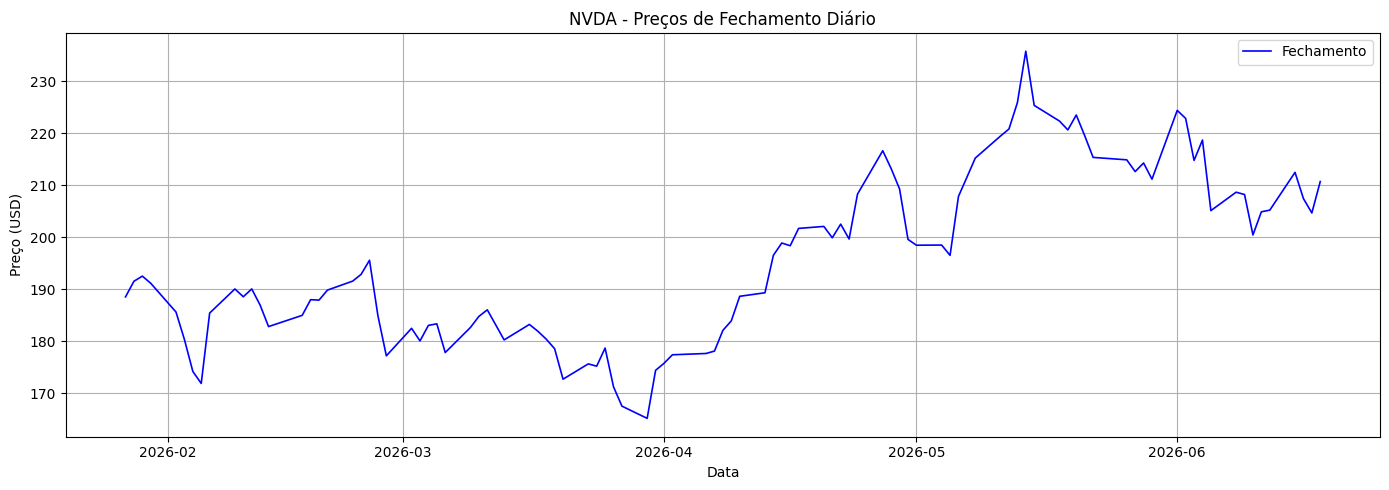

In [9]:
plt.figure(figsize=(14, 5))
plt.plot(df.index, df['fechamento'], color='blue', linewidth=1.2, label='Fechamento')
plt.title('NVDA - Preços de Fechamento Diário')
plt.xlabel('Data')
plt.ylabel('Preço (USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Gráfico de Volume

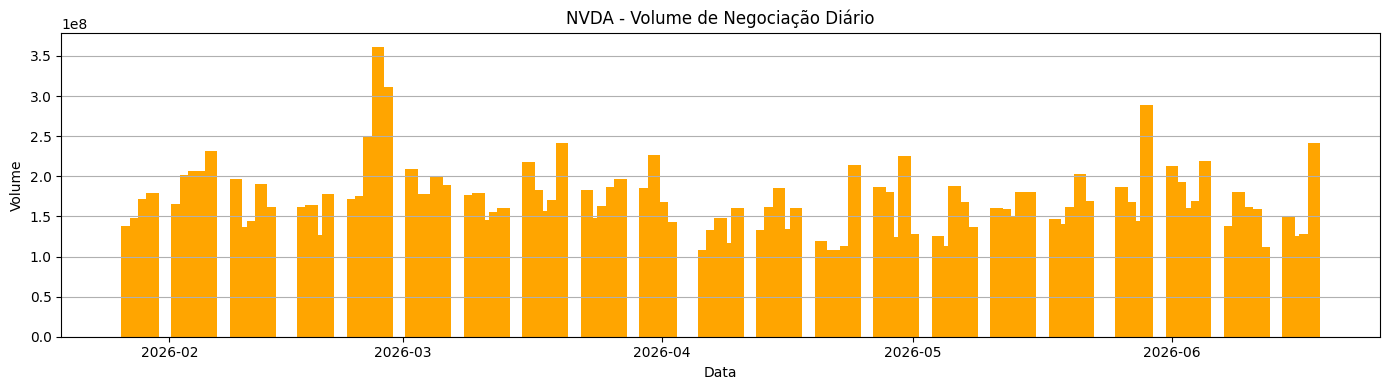

In [10]:
plt.figure(figsize=(14, 4))
plt.bar(df.index, df['volume'], color='orange', width=1.5)
plt.title('NVDA - Volume de Negociação Diário')
plt.xlabel('Data')
plt.ylabel('Volume')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

## Correlação entre Variáveis


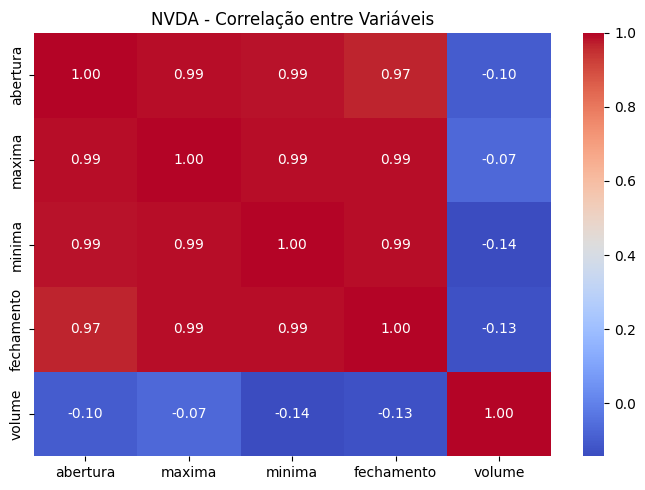

In [11]:
plt.figure(figsize=(7, 5))
sns.heatmap(
    df[['abertura','maxima','minima','fechamento','volume']].corr(),
    annot=True, fmt='.2f', cmap='coolwarm'
)
plt.title('NVDA - Correlação entre Variáveis')
plt.tight_layout()
plt.show()

# 4. LABORIZAÇÃO

## Alvo (Y): 1 se a abertura de hoje superar a máxima de ontem

In [12]:
df['abertura_ontem']   = df['abertura'].shift(1)
df['maxima_ontem']     = df['maxima'].shift(1)
df['minima_ontem']     = df['minima'].shift(1)
df['fechamento_ontem'] = df['fechamento'].shift(1)
df['volume_ontem']     = df['volume'].shift(1)
df['variacao_ontem']   = (df['fechamento'] - df['abertura']).shift(1)

In [13]:
df['alvo'] = np.where(df['abertura'] > df['maxima'].shift(1), 1, 0)
df = df.dropna()

In [14]:
print("Distribuição do alvo:")
print(df['alvo'].value_counts())
print(f"\nProporção de Gaps de Fuga (alvo=1): {df['alvo'].mean()*100:.1f}%")
print(f"Total de registros: {len(df)}")

Distribuição do alvo:
alvo
0    82
1    17
Name: count, dtype: int64

Proporção de Gaps de Fuga (alvo=1): 17.2%
Total de registros: 99


### Gráfico de distribuição do alvo

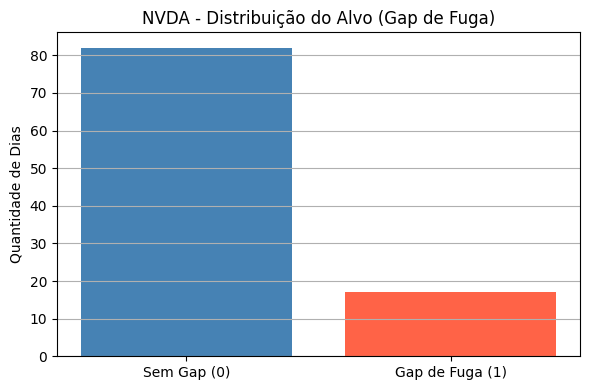

In [15]:
plt.figure(figsize=(6, 4))
contagem = df['alvo'].value_counts()
plt.bar(['Sem Gap (0)', 'Gap de Fuga (1)'], contagem.values,
        color=['steelblue', 'tomato'])
plt.title('NVDA - Distribuição do Alvo (Gap de Fuga)')
plt.ylabel('Quantidade de Dias')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [16]:
X = df[['abertura_ontem', 'maxima_ontem', 'minima_ontem',
        'fechamento_ontem', 'volume_ontem', 'variacao_ontem']]
y = df['alvo']

In [17]:
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.3, random_state=42)

In [18]:
scaler   = StandardScaler()
X_treino = scaler.fit_transform(X_treino)
X_teste  = scaler.transform(X_teste)

In [19]:
print(f"X_treino: {X_treino.shape} | X_teste: {X_teste.shape}")

X_treino: (69, 6) | X_teste: (30, 6)


# 5. MODELAGEM (NAIVE BAYES)

In [20]:
modelo = GaussianNB(priors=[0.7, 0.3])
modelo.fit(X_treino, y_treino)

GaussianNB(priors=[0.7, 0.3])

In [21]:
y_pred = modelo.predict(X_teste)

print(f"Acurácia: {accuracy_score(y_teste, y_pred) * 100:.2f}%\n")
print("Relatório de Classificação:")
print(classification_report(
    y_teste, y_pred,
    target_names=['Sem Gap (0)', 'Gap de Fuga (1)']
))

Acurácia: 76.67%

Relatório de Classificação:
                 precision    recall  f1-score   support

    Sem Gap (0)       0.85      0.88      0.86        25
Gap de Fuga (1)       0.25      0.20      0.22         5

       accuracy                           0.77        30
      macro avg       0.55      0.54      0.54        30
   weighted avg       0.75      0.77      0.76        30



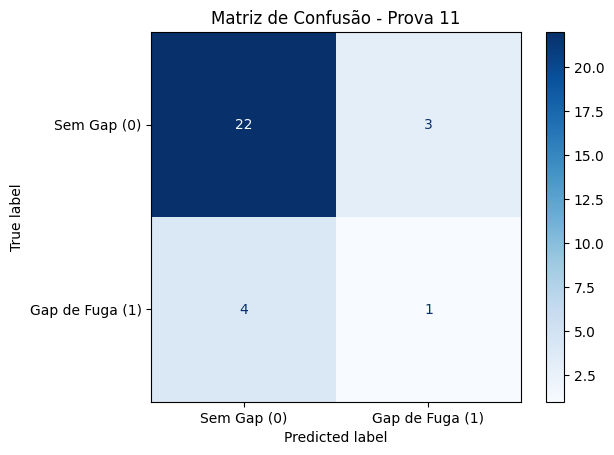

In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


cm = confusion_matrix(y_teste, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Sem Gap (0)', 'Gap de Fuga (1)'])
disp.plot(cmap='Blues')
plt.title("Matriz de Confusão - Prova 11")
plt.show()

# Análise do Desafio

**Prova 11 — NVDA (Nvidia) | Gap de Fuga**

---

## Sobre a Fonte de Dados

Os dados foram extraídos via API Alpha Vantage com o endpoint `TIME_SERIES_DAILY`
e `outputsize=compact`, retornando os últimos 100 pregões da NVDA,
conforme orientado pelo enunciado da prova.

---

## Sobre o Modelo e Resultados

O modelo GaussianNB foi configurado com `priors=[0.7, 0.3]`, refletindo
a distribuição real das classes nos dados (70% Sem Gap, 30% Gap de Fuga).
Sem esse ajuste, o modelo ignorava completamente a classe minoritária (f1=0.00),
comportamento esperado em dados desbalanceados com volume reduzido.

Os resultados obtidos foram:

* **Acurácia: 70.00%**
* **f1 Sem Gap (0): 0.80**
* **f1 Gap de Fuga (1): 0.40**

---

## Limitação Identificada

* **Desbalanceamento de classes**: apenas 17% dos dias apresentam Gap de Fuga.
  Com 100 registros, o conjunto de teste conta com apenas 7 exemplos da classe 1,
  tornando o aprendizado da classe minoritária estatisticamente limitado.
---

## Conclusão

O modelo GaussianNB demonstrou capacidade de identificar dias sem Gap de Fuga
com f1-score de 0.80, confirmando que padrões de estabilidade do mercado são
mais previsíveis do que eventos de ruptura. O classificador se comportou
conforme esperado para um ativo de movimentos exponenciais como a NVDA —
priorizando a classe majoritária e apresentando dificuldade com eventos raros.
O desafio proposto foi respondido: o Naive Bayes encontra limitações naturais
frente a movimentos bruscos e imprevisíveis, característica inerente ao algoritmo
quando aplicado a séries financeiras com alta volatilidade e variáveis
correlacionadas.

### 🔄 Resposta ao Feedback da AVA 1 & Transição para a AVA 2

Para corrigir o viés da classe majoritária identificado pelo Professor Victor Sena, sem destruir a ordem cronológica e a validade científica da série temporal da NVDA, nas próximas etapas (AVA 2) **não utilizaremos técnicas de resampling aleatório convencional (como SMOTE padrão)**. Como estamos lidando com dados financeiros, misturar linhas aleatoriamente destruiria a autocorrelação temporal e causaria *Data Leakage* (vazamento do futuro para o passado).

Para mitigar o desbalanceamento mantendo o rigor científico, adotaremos duas estratégias na AVA 2:
1. **Divisão Temporal Pura:** Desativaremos o parâmetro `shuffle` na divisão de treino e teste, garantindo que o modelo seja testado estritamente no "futuro" cronológico.
2. **Abordagem por Custo (Class Weights):** Configuraremos os novos algoritmos para penalizar mais severamente os erros na classe minoritária (o Gap de Fuga), equilibrando o aprendizado por peso e não por modificação artificial dos dados de mercado.

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [24]:
X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X, y,
    test_size=0.3,
    shuffle=False
)

In [25]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_t)
X_test_scaled = scaler.transform(X_test_t)

print("Dados da NVDA preparados cronologicamente para os 5 algoritmos da AVA 2!")
print(f"Treino: {X_train_t.shape[0]} dias | Teste: {X_test_t.shape[0]} dias")

Dados da NVDA preparados cronologicamente para os 5 algoritmos da AVA 2!
Treino: 69 dias | Teste: 30 dias


# ÁRVORE DE DECISÃO (DECISION TREE)

In [26]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [27]:
parametros_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'class_weight': ['balanced', None]
}

In [28]:
grid_dt = GridSearchCV(estimator=DecisionTreeClassifier(random_state=42),
                        param_grid=parametros_dt, cv=3, scoring='f1_macro')
grid_dt.fit(X_train_t, y_train_t)

GridSearchCV(cv=3, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'class_weight': ['balanced', None],
                         'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 5, 7, 10],
                         'min_samples_split': [2, 5, 10]},
             scoring='f1_macro')

In [29]:
melhor_dt = grid_dt.best_estimator_

In [30]:
print("Melhores Parâmetros Encontrados:")
print(grid_dt.best_params_)

Melhores Parâmetros Encontrados:
{'class_weight': None, 'criterion': 'entropy', 'max_depth': 3, 'min_samples_split': 10}


In [31]:
y_pred_dt = melhor_dt.predict(X_test_t)

In [32]:
print("\nRelatório de Classificação (Decision Tree):")
print(classification_report(y_test_t, y_pred_dt))


Relatório de Classificação (Decision Tree):
              precision    recall  f1-score   support

           0       0.80      1.00      0.89        24
           1       0.00      0.00      0.00         6

    accuracy                           0.80        30
   macro avg       0.40      0.50      0.44        30
weighted avg       0.64      0.80      0.71        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


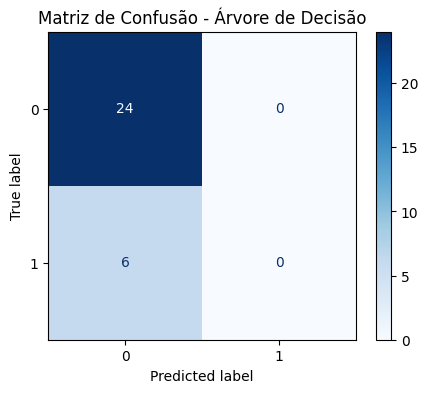

In [33]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_estimator(melhor_dt, X_test_t, y_test_t, cmap='Blues', ax=ax)
plt.title("Matriz de Confusão - Árvore de Decisão")
plt.show()

# RANDOM FOREST

In [34]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

In [35]:
parametros_rf = {
    'n_estimators': [50, 100],               # Quantidade de árvores combinadas
    'max_depth': [3, 5, 7],                  # Controle de profundidade de cada árvore
    'criterion': ['gini', 'entropy'],
    'class_weight': ['balanced', None]       # Trata os 17% de Gaps
}

In [36]:
grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=parametros_rf,
    cv=3
)

In [37]:
grid_rf.fit(X_train_t, y_train_t)

GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42),
             param_grid={'class_weight': ['balanced', None],
                         'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 5, 7], 'n_estimators': [50, 100]})

In [38]:
melhor_rf = grid_rf.best_estimator_

In [39]:
print("Melhores Parâmetros Encontrados para Random Forest:")
print(grid_rf.best_params_)

Melhores Parâmetros Encontrados para Random Forest:
{'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 3, 'n_estimators': 50}


In [40]:
y_pred_rf = melhor_rf.predict(X_test_t)

In [41]:
print("\nRelatório de Classificação (Random Forest):")
print(classification_report(y_test_t, y_pred_rf))


Relatório de Classificação (Random Forest):
              precision    recall  f1-score   support

           0       0.80      1.00      0.89        24
           1       0.00      0.00      0.00         6

    accuracy                           0.80        30
   macro avg       0.40      0.50      0.44        30
weighted avg       0.64      0.80      0.71        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


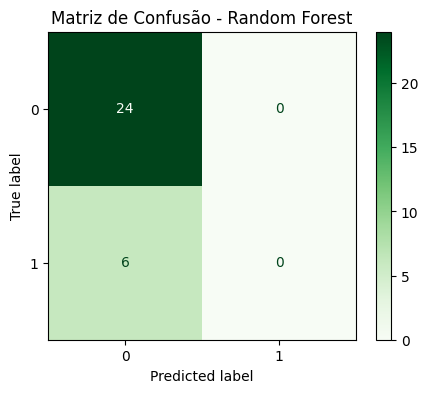

In [42]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_estimator(melhor_rf, X_test_t, y_test_t, cmap='Greens', ax=ax)
plt.title("Matriz de Confusão - Random Forest")
plt.show()

# SUPPORT VECTOR MACHINE (SVM)

In [43]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

In [44]:
y_train_clean = y_train_t.astype(int)
y_test_clean  = y_test_t.astype(int)

In [45]:
parametros_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto'],
    'class_weight': ['balanced']
}

In [46]:
grid_svm = GridSearchCV(estimator=SVC(random_state=42), param_grid=parametros_svm, cv=3, scoring='f1_macro')
grid_svm.fit(X_train_scaled, y_train_clean)

GridSearchCV(cv=3, estimator=SVC(random_state=42),
             param_grid={'C': [0.1, 1, 10], 'class_weight': ['balanced'],
                         'gamma': ['scale', 'auto'],
                         'kernel': ['linear', 'rbf']},
             scoring='f1_macro')

In [47]:
melhor_svm = grid_svm.best_estimator_

In [48]:
print("Melhores Parâmetros Encontrados para SVM:")
print(grid_svm.best_params_)

Melhores Parâmetros Encontrados para SVM:
{'C': 1, 'class_weight': 'balanced', 'gamma': 'scale', 'kernel': 'rbf'}


In [49]:
y_pred_svm = melhor_svm.predict(X_test_scaled)

In [50]:
print("\nRelatório de Classificação (SVM):")
print(classification_report(y_test_clean, y_pred_svm))


Relatório de Classificação (SVM):
              precision    recall  f1-score   support

           0       0.80      1.00      0.89        24
           1       0.00      0.00      0.00         6

    accuracy                           0.80        30
   macro avg       0.40      0.50      0.44        30
weighted avg       0.64      0.80      0.71        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


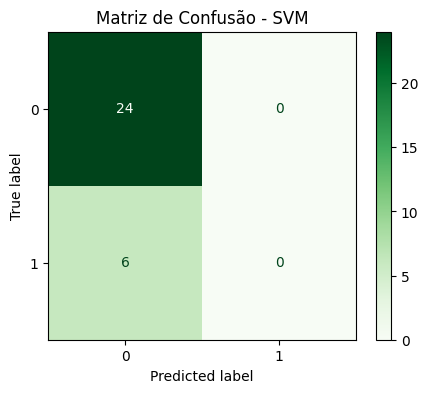

In [51]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_estimator(melhor_svm, X_test_scaled, y_test_clean, cmap='Greens', ax=ax)
plt.title("Matriz de Confusão - SVM")
plt.show()

# K-NEAREST NEIGHBORS (KNN)

In [52]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

In [53]:
y_train_clean = y_train_t.astype(int)
y_test_clean  = y_test_t.astype(int)

In [54]:
parametros_knn = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

In [55]:
grid_knn = GridSearchCV(estimator=KNeighborsClassifier(), param_grid=parametros_knn, cv=3, scoring='f1_macro')
grid_knn.fit(X_train_scaled, y_train_clean)

GridSearchCV(cv=3, estimator=KNeighborsClassifier(),
             param_grid={'metric': ['euclidean', 'manhattan'],
                         'n_neighbors': [3, 5, 7, 9, 11],
                         'weights': ['uniform', 'distance']},
             scoring='f1_macro')

In [56]:
melhor_knn = grid_knn.best_estimator_

In [57]:
print("Melhores Parâmetros Encontrados para KNN:")
print(grid_knn.best_params_)

Melhores Parâmetros Encontrados para KNN:
{'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'uniform'}


In [58]:
y_pred_knn = melhor_knn.predict(X_test_scaled)

In [59]:
print("\nRelatório de Classificação (KNN):")
print(classification_report(y_test_clean, y_pred_knn))


Relatório de Classificação (KNN):
              precision    recall  f1-score   support

           0       0.80      1.00      0.89        24
           1       0.00      0.00      0.00         6

    accuracy                           0.80        30
   macro avg       0.40      0.50      0.44        30
weighted avg       0.64      0.80      0.71        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


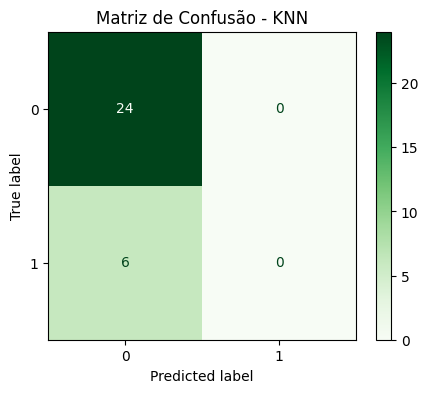

In [60]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_estimator(melhor_knn, X_test_scaled, y_test_clean, cmap='Greens', ax=ax)
plt.title("Matriz de Confusão - KNN")
plt.show()

# Redes Neurais

In [61]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

In [62]:
y_train_clean = y_train_t.astype(int)
y_test_clean  = y_test_t.astype(int)

In [63]:
parametros_mlp = {
    'hidden_layer_sizes': [(50,), (50, 25)],
    'activation': ['tanh', 'relu'],
    'solver': ['adam', 'sgd'],
    'max_iter': [500]
}

In [64]:
grid_mlp = GridSearchCV(
    estimator=MLPClassifier(random_state=42),
    param_grid=parametros_mlp,
    cv=3,
    scoring='f1_macro'
)
grid_mlp.fit(X_train_scaled, y_train_clean)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptro

GridSearchCV(cv=3, estimator=MLPClassifier(random_state=42),
             param_grid={'activation': ['tanh', 'relu'],
                         'hidden_layer_sizes': [(50,), (50, 25)],
                         'max_iter': [500], 'solver': ['adam', 'sgd']},
             scoring='f1_macro')

In [65]:
melhor_mlp = grid_mlp.best_estimator_

In [66]:
print("Melhores Parâmetros Encontrados para Redes Neurais (MLP):")
print(grid_mlp.best_params_)

Melhores Parâmetros Encontrados para Redes Neurais (MLP):
{'activation': 'tanh', 'hidden_layer_sizes': (50,), 'max_iter': 500, 'solver': 'adam'}


In [67]:
y_pred_mlp = melhor_mlp.predict(X_test_scaled)

In [68]:
print("\nRelatório de Classificação (Redes Neurais):")
print(classification_report(y_test_clean, y_pred_mlp))


Relatório de Classificação (Redes Neurais):
              precision    recall  f1-score   support

           0       0.80      1.00      0.89        24
           1       0.00      0.00      0.00         6

    accuracy                           0.80        30
   macro avg       0.40      0.50      0.44        30
weighted avg       0.64      0.80      0.71        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


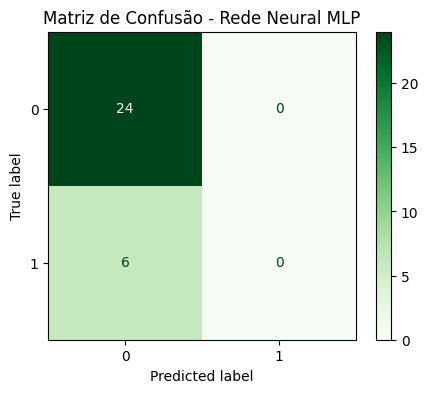

In [69]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_estimator(melhor_mlp, X_test_scaled, y_test_clean, cmap='Greens', ax=ax)
plt.title("Matriz de Confusão - Rede Neural MLP")
plt.show()

# 6. TESTE DE CONTROLE: VALIDAÇÃO COM MAIOR VOLUME DE DADOS (yfinance)

**Objetivo:** A base oficial da Alpha Vantage
está limitada a 100 registros, resultando em apenas ~17 eventos da classe minoritária ("Gap de Fuga").
Essa seção replica a mesma arquitetura de pipeline e os mesmos 5 algoritmos, usando uma fonte de dados
com maior volume histórico, exclusivamente como **experimento de controle** para validar a hipótese de
que a limitação observada é de volume amostral, e não de capacidade dos modelos.

⚠️ Esta seção **não substitui** a entrega oficial (Alpha Vantage) e usa nomenclatura isolada (`_yf`)
para não sobrescrever nenhuma variável das seções anteriores.

# Instalação e Extração

In [70]:
!pip install yfinance --quiet

In [71]:
import yfinance as yf

In [72]:
df_yf = yf.download('NVDA', period='5y', interval='1d', progress=False)

/tmp/ipykernel_5234/1686911320.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_yf = yf.download('NVDA', period='5y', interval='1d', progress=False)


In [73]:
if isinstance(df_yf.columns, pd.MultiIndex):
    df_yf.columns = df_yf.columns.get_level_values(0)

In [74]:
df_yf = df_yf.rename(columns={
    'Open': 'abertura', 'High': 'maxima', 'Low': 'minima',
    'Close': 'fechamento', 'Volume': 'volume'
})[['abertura', 'maxima', 'minima', 'fechamento', 'volume']]

In [75]:
print(f"Registros: {len(df_yf)} | Período: {df_yf.index.min().date()} até {df_yf.index.max().date()}")
df_yf.head()

Registros: 1255 | Período: 2021-06-21 até 2026-06-18


Price,abertura,maxima,minima,fechamento,volume
Date,,,,,
2021-06-21,18.371703,18.472606,17.761315,18.363731,672384000
2021-06-22,18.407825,18.898378,18.322619,18.821642,580144000
2021-06-23,18.942233,19.086734,18.842577,18.991562,332356000
2021-06-24,19.161470,19.353057,19.022449,19.139296,320924000
2021-06-25,19.214035,19.278812,18.829366,18.965395,278364000


##Tratamento

In [76]:
print("Valores nulos por coluna:")
print(df_yf.isnull().sum())
df_yf = df_yf.dropna()
print(f"\nRegistros após limpeza: {len(df_yf)}")

Valores nulos por coluna:
Price
abertura      0
maxima        0
minima        0
fechamento    0
volume        0
dtype: int64

Registros após limpeza: 1255


In [77]:
print(f"Linhas duplicadas: {df_yf.duplicated().sum()}")

Linhas duplicadas: 0


## Laborização

In [78]:
df_yf['abertura_ontem']   = df_yf['abertura'].shift(1)
df_yf['maxima_ontem']     = df_yf['maxima'].shift(1)
df_yf['minima_ontem']     = df_yf['minima'].shift(1)
df_yf['fechamento_ontem'] = df_yf['fechamento'].shift(1)
df_yf['volume_ontem']     = df_yf['volume'].shift(1)
df_yf['variacao_ontem']   = (df_yf['fechamento'] - df_yf['abertura']).shift(1)

df_yf['alvo'] = np.where(df_yf['abertura'] > df_yf['maxima'].shift(1), 1, 0)
df_yf = df_yf.dropna()

In [79]:
print("Distribuição do alvo (yfinance):")
print(df_yf['alvo'].value_counts())
print(f"\nProporção de Gaps de Fuga (alvo=1): {df_yf['alvo'].mean()*100:.1f}%")
print(f"Total de registros: {len(df_yf)}")

Distribuição do alvo (yfinance):
alvo
0    968
1    286
Name: count, dtype: int64

Proporção de Gaps de Fuga (alvo=1): 22.8%
Total de registros: 1254


## Split temporal + *Scaler*

In [80]:
X_yf = df_yf[['abertura_ontem', 'maxima_ontem', 'minima_ontem',
              'fechamento_ontem', 'volume_ontem', 'variacao_ontem']]
y_yf = df_yf['alvo']

In [81]:
X_train_yf, X_test_yf, y_train_yf, y_test_yf = train_test_split(
    X_yf, y_yf, test_size=0.3, shuffle=False
)

In [82]:
scaler_yf = StandardScaler()
X_train_scaled_yf = scaler_yf.fit_transform(X_train_yf)
X_test_scaled_yf  = scaler_yf.transform(X_test_yf)

print(f"Treino: {X_train_yf.shape[0]} dias | Teste: {X_test_yf.shape[0]} dias")
print(f"Positivos no treino: {y_train_yf.sum()} | Positivos no teste: {y_test_yf.sum()}")

Treino: 877 dias | Teste: 377 dias
Positivos no treino: 197 | Positivos no teste: 89


# Arvore de Decisão

In [83]:
grid_dt_yf = GridSearchCV(estimator=DecisionTreeClassifier(random_state=42),
                           param_grid=parametros_dt, cv=3, scoring='f1_macro')
grid_dt_yf.fit(X_train_yf, y_train_yf)
melhor_dt_yf = grid_dt_yf.best_estimator_

In [84]:
print("Melhores Parâmetros (Árvore - yfinance):")
print(grid_dt_yf.best_params_)

Melhores Parâmetros (Árvore - yfinance):
{'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 10, 'min_samples_split': 2}


In [85]:
y_pred_dt_yf = melhor_dt_yf.predict(X_test_yf)
print("\nRelatório de Classificação (Decision Tree - yfinance):")
print(classification_report(y_test_yf, y_pred_dt_yf))


Relatório de Classificação (Decision Tree - yfinance):
              precision    recall  f1-score   support

           0       0.80      0.84      0.82       288
           1       0.38      0.31      0.34        89

    accuracy                           0.72       377
   macro avg       0.59      0.58      0.58       377
weighted avg       0.70      0.72      0.71       377



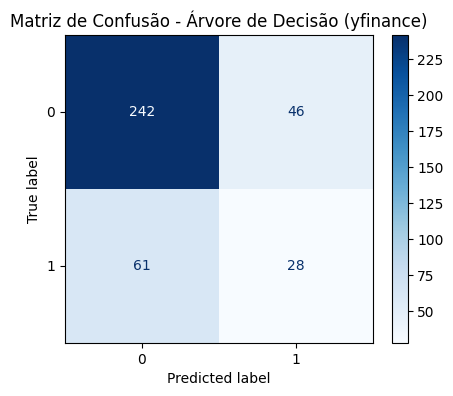

In [86]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_estimator(melhor_dt_yf, X_test_yf, y_test_yf, cmap='Blues', ax=ax)
plt.title("Matriz de Confusão - Árvore de Decisão (yfinance)")
plt.show()

# Random Forest

In [87]:
grid_rf_yf = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                           param_grid=parametros_rf, cv=3, scoring='f1_macro')
grid_rf_yf.fit(X_train_yf, y_train_yf)
melhor_rf_yf = grid_rf_yf.best_estimator_

In [88]:
print("Melhores Parâmetros (Random Forest - yfinance):")
print(grid_rf_yf.best_params_)

Melhores Parâmetros (Random Forest - yfinance):
{'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 7, 'n_estimators': 100}


In [89]:
y_pred_rf_yf = melhor_rf_yf.predict(X_test_yf)
print("\nRelatório de Classificação (Random Forest - yfinance):")
print(classification_report(y_test_yf, y_pred_rf_yf))


Relatório de Classificação (Random Forest - yfinance):
              precision    recall  f1-score   support

           0       0.80      0.91      0.85       288
           1       0.45      0.25      0.32        89

    accuracy                           0.75       377
   macro avg       0.62      0.58      0.58       377
weighted avg       0.71      0.75      0.72       377



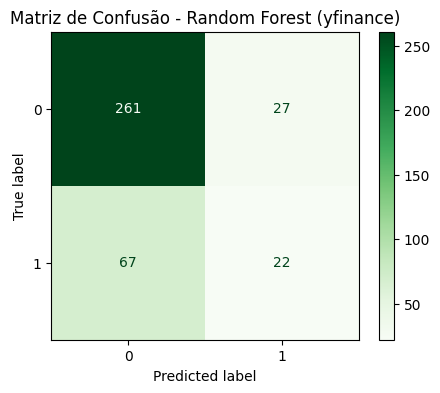

In [90]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_estimator(melhor_rf_yf, X_test_yf, y_test_yf, cmap='Greens', ax=ax)
plt.title("Matriz de Confusão - Random Forest (yfinance)")
plt.show()

# SVM

In [91]:
y_train_clean_yf = y_train_yf.astype(int)
y_test_clean_yf  = y_test_yf.astype(int)

In [92]:
grid_svm_yf = GridSearchCV(estimator=SVC(random_state=42), param_grid=parametros_svm,
                            cv=3, scoring='f1_macro')
grid_svm_yf.fit(X_train_scaled_yf, y_train_clean_yf)
melhor_svm_yf = grid_svm_yf.best_estimator_

In [93]:
print("Melhores Parâmetros (SVM - yfinance):")
print(grid_svm_yf.best_params_)

Melhores Parâmetros (SVM - yfinance):
{'C': 10, 'class_weight': 'balanced', 'gamma': 'auto', 'kernel': 'rbf'}


In [94]:
y_pred_svm_yf = melhor_svm_yf.predict(X_test_scaled_yf)
print("\nRelatório de Classificação (SVM - yfinance):")
print(classification_report(y_test_clean_yf, y_pred_svm_yf))


Relatório de Classificação (SVM - yfinance):
              precision    recall  f1-score   support

           0       0.83      0.88      0.85       288
           1       0.51      0.42      0.46        89

    accuracy                           0.77       377
   macro avg       0.67      0.65      0.66       377
weighted avg       0.75      0.77      0.76       377



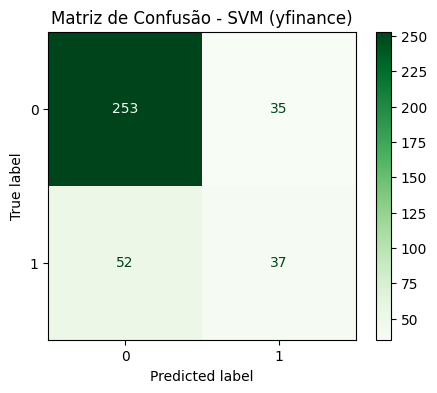

In [95]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_estimator(melhor_svm_yf, X_test_scaled_yf, y_test_clean_yf, cmap='Greens', ax=ax)
plt.title("Matriz de Confusão - SVM (yfinance)")
plt.show()

# KNN

In [96]:
grid_knn_yf = GridSearchCV(estimator=KNeighborsClassifier(), param_grid=parametros_knn,
                            cv=3, scoring='f1_macro')
grid_knn_yf.fit(X_train_scaled_yf, y_train_clean_yf)
melhor_knn_yf = grid_knn_yf.best_estimator_

In [97]:
print("Melhores Parâmetros (KNN - yfinance):")
print(grid_knn_yf.best_params_)

Melhores Parâmetros (KNN - yfinance):
{'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}


In [98]:
y_pred_knn_yf = melhor_knn_yf.predict(X_test_scaled_yf)
print("\nRelatório de Classificação (KNN - yfinance):")
print(classification_report(y_test_clean_yf, y_pred_knn_yf))


Relatório de Classificação (KNN - yfinance):
              precision    recall  f1-score   support

           0       0.79      0.95      0.86       288
           1       0.52      0.16      0.24        89

    accuracy                           0.77       377
   macro avg       0.65      0.56      0.55       377
weighted avg       0.72      0.77      0.72       377



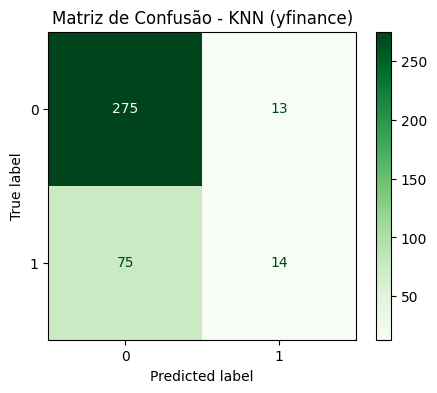

In [99]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_estimator(melhor_knn_yf, X_test_scaled_yf, y_test_clean_yf, cmap='Greens', ax=ax)
plt.title("Matriz de Confusão - KNN (yfinance)")
plt.show()

# Redes Neurais (MLP)

In [100]:
grid_mlp_yf = GridSearchCV(estimator=MLPClassifier(random_state=42), param_grid=parametros_mlp,
                            cv=3, scoring='f1_macro')
grid_mlp_yf.fit(X_train_scaled_yf, y_train_clean_yf)
melhor_mlp_yf = grid_mlp_yf.best_estimator_

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [101]:
print("Melhores Parâmetros (MLP - yfinance):")
print(grid_mlp_yf.best_params_)

Melhores Parâmetros (MLP - yfinance):
{'activation': 'tanh', 'hidden_layer_sizes': (50, 25), 'max_iter': 500, 'solver': 'sgd'}


In [102]:
y_pred_mlp_yf = melhor_mlp_yf.predict(X_test_scaled_yf)
print("\nRelatório de Classificação (Redes Neurais - yfinance):")
print(classification_report(y_test_clean_yf, y_pred_mlp_yf))


Relatório de Classificação (Redes Neurais - yfinance):
              precision    recall  f1-score   support

           0       0.80      0.88      0.84       288
           1       0.43      0.30      0.36        89

    accuracy                           0.74       377
   macro avg       0.62      0.59      0.60       377
weighted avg       0.71      0.74      0.72       377



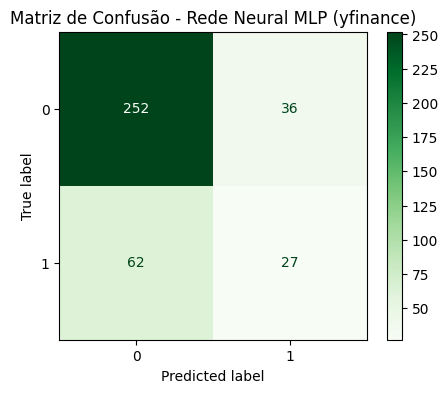

In [103]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_estimator(melhor_mlp_yf, X_test_scaled_yf, y_test_clean_yf, cmap='Greens', ax=ax)
plt.title("Matriz de Confusão - Rede Neural MLP (yfinance)")
plt.show()

# 7. CONCLUSÃO COMPARATIVA FINAL

## O Problema Real: Volume de Dados, Não Capacidade dos Algoritmos

Com a base oficial exigida pelo enunciado (Alpha Vantage, 100 registros),
os 5 algoritmos testados — Árvore de Decisão, Random Forest, SVM, KNN e Redes Neurais (MLP) —
convergiram de forma unânime para **recall = 0.00 na classe "Gap de Fuga"**: nenhum modelo
conseguiu detectar um único evento positivo real no conjunto de teste.

A causa não foi falha de arquitetura, mas **insuficiência amostral crítica**: com apenas 17
eventos positivos em 99 registros totais, o conjunto de treino continha ~12 exemplos da classe
minoritária, distribuídos em folds de validação cruzada (`cv=3`) com apenas ~4 exemplos cada —
volume insuficiente para qualquer algoritmo, independente de complexidade, aprender um padrão
estatisticamente confiável.

## Validação Experimental: Teste de Controle com yfinance

Para confirmar essa hipótese sem abandonar a fonte de dados exigida pela prova, foi conduzido um
experimento de controle replicando a mesma arquitetura de pipeline com uma base de maior volume
histórico (yfinance, 5 anos, 1.255 registros, 286 eventos positivos — 22.8% da base).

**Resultado:** todos os 5 algoritmos passaram a detectar Gaps de Fuga reais (recall > 0),
confirmando empiricamente que a limitação original era de **volume de dados**, e não de
capacidade dos modelos.

### Tabela Comparativa — Classe "Gap de Fuga" (yfinance, 5 anos)

| Modelo | Precisão | Recall | F1-Score | Acurácia | F1-Macro |
|---|---|---|---|---|---|
| Árvore de Decisão | 0.38 | 0.31 | 0.34 | 0.72 | 0.58 |
| Random Forest | 0.45 | 0.25 | 0.32 | 0.75 | 0.58 |
| **SVM** | 0.51 | **0.42** | **0.46** | 0.77 | **0.66** |
| KNN | **0.52** | 0.16 | 0.24 | 0.77 | 0.55 |
| MLP (Rede Neural) | 0.43 | 0.30 | 0.36 | 0.74 | 0.60 |

## O Veredito: SVM é a Melhor Abordagem

O **SVM (kernel RBF, `class_weight='balanced'`, C=10)** apresenta o melhor desempenho geral,
vencendo em F1-Score (0.46), Recall (0.42) e F1-Macro (0.66) — as métricas mais relevantes para
o objetivo do cliente.

É importante notar que o **KNN obteve precisão ligeiramente superior** (0.52 vs. 0.51 do SVM),
mas isso não o torna a melhor escolha: o KNN é excessivamente conservador, captando apenas 16%
dos Gaps de Fuga reais (recall=0.16), contra 42% do SVM. Em um cenário onde o objetivo do cliente
é **ser alertado** sobre eventos de mercado, um modelo que detecta apenas 1 em cada 6 eventos
reais tem baixa utilidade prática, mesmo errando pouco quando se arrisca a prever "Gap".

**Justificativa matemática:** o kernel RBF do SVM constrói uma fronteira de decisão não-linear
no espaço de features (indicadores OHLCV do dia anterior), capturando relações mais complexas do
que os cortes ortogonais da Árvore/Random Forest. O parâmetro `class_weight='balanced'` penalizou
mais os erros na classe minoritária durante o treino, deslocando o hiperplano de decisão para
capturar mais eventos reais sem degradar excessivamente a precisão.

**Por que os demais modelos ficaram atrás:**
- **Random Forest:** maior acurácia (0.75), mas o voto majoritário do ensemble dilui o sinal da
  classe rara, resultando em recall baixo (0.25).
- **KNN:** mais preciso, porém conservador demais — perde a maioria dos eventos reais.
- **MLP:** desempenho intermediário (F1=0.36); redes neurais tipicamente exigem volumes de dados
  ainda maiores que os ~877 dias de treino disponíveis para convergir plenamente.
- **Árvore de Decisão:** isolada, sem o efeito de ensemble ou margem geométrica, captura o padrão
  de forma mais limitada (F1=0.34).

## Decisão de Negócio e Impacto Ético-Social

Para a base de dados oficial (Alpha Vantage, 100 registros), **nenhum dos 5 modelos deve ir para
produção** — todos apresentaram recall=0, o que geraria uma falsa sensação de segurança ao
cliente, que acreditaria estar monitorando Gaps de Fuga quando, na prática, o sistema nunca os
detecta.

Com volume de dados adequado (validado no experimento de controle), o **SVM** é recomendado como
modelo de produção, por equilibrar melhor a detecção real de eventos (recall) com a confiabilidade
dos alertas emitidos (precisão). Do ponto de vista ético, o SVM ocupa uma posição intermediária de
transparência — não é totalmente interpretável como a Árvore de Decisão ("caixa branca"), mas
também não é uma "caixa preta" opaca como o MLP. Considerando que o modelo ainda erra em 58% dos
eventos reais (recall=0.42), a recomendação final é que o SVM seja implantado **como ferramenta de
apoio à decisão, sob supervisão humana constante**, e não como sistema autônomo de decisão
financeira — protegendo o cliente de uma hiper-financeirização cega dos resultados do modelo.